# 6. 간선 비용 함수 정의 + 다익스트라 준비

## 1) import & 데이터 로드

In [1]:
import shapely.geometry as geom
import shapely.ops as ops
import pickle, networkx as nx, pandas as pd
from pathlib import Path

In [2]:
# === 셀 0: ShadowRect 정의 (언피클보다 먼저 실행!) ===
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
import math

@dataclass
class ShadowRect:
    cx: float      # 직사각형 중심 x  (center = c + (L/2)·d)
    cy: float      # 직사각형 중심 y
    length: float  # L
    width: float   # 2r
    dx: float      # d_x (태양 반대 단위벡터)
    dy: float      # d_y
    meta: Dict[str, Any]

    def endpoints(self) -> Tuple[Tuple[float,float], Tuple[float,float]]:
        """중심선 양끝점 (start, end). start는 건물 중심 c, end는 c + L·d와 거의 일치."""
        hx = 0.5 * self.length * self.dx
        hy = 0.5 * self.length * self.dy
        # 중심선 = [center - (L/2)d, center + (L/2)d]
        return (self.cx - hx, self.cy - hy), (self.cx + hx, self.cy + hy)

    def corners(self) -> List[Tuple[float, float]]:
        """
        직사각형 꼭짓점 4개를 시계방향으로 반환.
        길이 방향 단위벡터 = (dx,dy), 폭 방향 법선 = (-dy, dx).
        """
        hx = 0.5 * self.length * self.dx
        hy = 0.5 * self.length * self.dy
        nx, ny = -self.dy, self.dx
        half_w = 0.5 * self.width

        c1x, c1y = self.cx - hx, self.cy - hy   # 중심선 시작(건물 중심 쪽)
        c2x, c2y = self.cx + hx, self.cy + hy   # 중심선 끝(그림자 끝)

        p1 = (c1x - half_w*nx, c1y - half_w*ny)
        p2 = (c1x + half_w*nx, c1y + half_w*ny)
        p3 = (c2x + half_w*nx, c2y + half_w*ny)
        p4 = (c2x - half_w*nx, c2y - half_w*ny)
        return [p1, p2, p3, p4]


In [3]:
ARTIFACTS_DIR = Path("../artifacts")

# 그래프 (ENU 좌표 포함)
with open(ARTIFACTS_DIR / "graph_xy.pkl", "rb") as f:
    G = pickle.load(f)

# 그림자 직사각형들
with open(ARTIFACTS_DIR / "shadow_rects.pkl", "rb") as f:
    shadow_rects = pickle.load(f)

# 태양정보 포함된 건물 데이터 (선택 확인용)
b_with_sun = pd.read_parquet(ARTIFACTS_DIR / "buildings_with_sun.parquet")

print("로드 완료:", G.number_of_nodes(), "nodes /", G.number_of_edges(), "edges /", len(shadow_rects), "rectangles")

로드 완료: 330 nodes / 440 edges / 87 rectangles


## 2) shapely Polygon으로 변환

In [4]:
shadow_polys = [geom.Polygon(r.corners()) for r in shadow_rects]
print("Shapely polygons:", len(shadow_polys))

Shapely polygons: 87


## 3) 간선별 교차 길이 계산

In [5]:
edge_data = []

for u, v, data in G.edges(data=True):
    x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
    x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]

    edge_line = geom.LineString([(x1, y1), (x2, y2)])
    edge_len = edge_line.length

    inter_parts = []
    for poly in shadow_polys:
        inter = edge_line.intersection(poly)
        if not inter.is_empty:
            inter_parts.append(inter)

    inter_len = 0.0
    if inter_parts:
        merged = ops.unary_union(inter_parts)
        # merged가 LineString/MultilineString이면 length가 교차 길이
        if hasattr(merged, "length"):
            inter_len = merged.length

    shadow_ratio = inter_len / edge_len if edge_len > 0 else 0.0

    edge_data.append({
        "u": u, "v": v,
        "edge_len": edge_len,
        "shadow_len": inter_len,
        "shadow_ratio": shadow_ratio
    })

print("샘플 5개:", edge_data[:10])

샘플 5개: [{'u': 1, 'v': 113, 'edge_len': 30.9827025368595, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 1, 'v': 198, 'edge_len': 36.912446641787426, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 2, 'v': 3, 'edge_len': 21.127036062061393, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 2, 'v': 211, 'edge_len': 12.39747251498426, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 2, 'v': 216, 'edge_len': 34.697137357763175, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 3, 'v': 207, 'edge_len': 36.7385305324175, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 4, 'v': 5, 'edge_len': 17.257852942658573, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 4, 'v': 217, 'edge_len': 13.967874017385617, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 4, 'v': 299, 'edge_len': 26.743391015521976, 'shadow_len': 0.0, 'shadow_ratio': 0.0}, {'u': 5, 'v': 213, 'edge_len': 17.825606319092035, 'shadow_len': 0.0, 'shadow_ratio': 0.0}]


## 4) DataFrame 저장

In [6]:
df_edges = pd.DataFrame(edge_data)
df_edges.to_parquet(ARTIFACTS_DIR / "edges_with_shadow.parquet", index=False)

print("저장 완료:", ARTIFACTS_DIR / "edges_with_shadow.parquet")
print(df_edges.describe())

저장 완료: ..\artifacts\edges_with_shadow.parquet
                u           v    edge_len  shadow_len  shadow_ratio
count  440.000000  440.000000  440.000000  440.000000    440.000000
mean   132.204545  225.254545   40.067478    0.912356      0.022228
std     83.224777   84.222202   19.290908    4.448632      0.099891
min      1.000000    3.000000    1.346488    0.000000      0.000000
25%     62.750000  176.750000   27.051443    0.000000      0.000000
50%    124.000000  251.000000   36.352800    0.000000      0.000000
75%    190.000000  291.000000   48.715009    0.000000      0.000000
max    329.000000  330.000000  133.981918   57.169528      1.000000


## 5) 통계 시각화

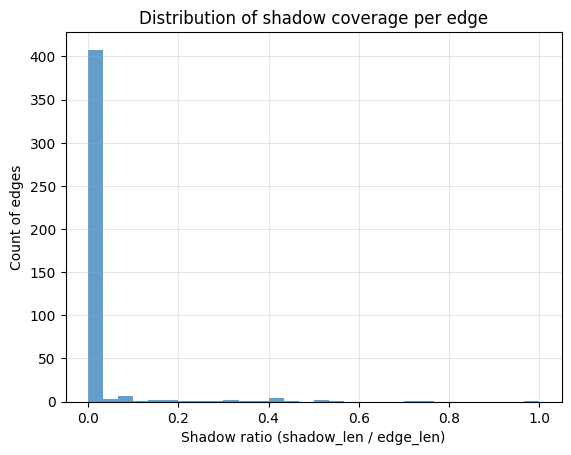

In [7]:
import matplotlib.pyplot as plt

plt.hist(df_edges["shadow_ratio"], bins=30, alpha=0.7)
plt.xlabel("Shadow ratio (shadow_len / edge_len)")
plt.ylabel("Count of edges")
plt.title("Distribution of shadow coverage per edge")
plt.grid(True, alpha=0.3)
plt.show()


## 추가) 그림자 + 간선 시각화

In [8]:
ARTIFACTS_DIR = Path("../artifacts")

with open(ARTIFACTS_DIR / "graph_xy.pkl", "rb") as f:
    G = pickle.load(f)

buildings = pd.read_parquet(ARTIFACTS_DIR / "buildings_xy.parquet").copy()

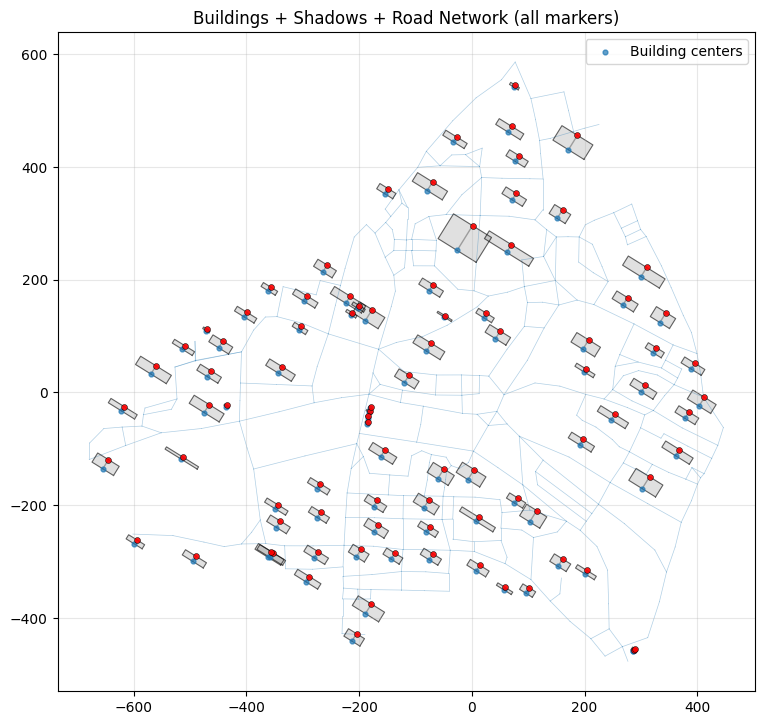

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,9))

# 1) 모든 건물 중심(파란 점)
ax.scatter(buildings["x"], buildings["y"],
           s=12, alpha=0.7, color="tab:blue", label="Building centers", zorder=2)

# 2) 모든 그림자 직사각형 (윤곽 + 채우기)
for r in shadow_rects:
    # 중심선
    (x_start, y_start), (x_end, y_end) = r.endpoints()
    ax.plot([x_start, x_end], [y_start, y_end],
            lw=1, alpha=0.7, color="gray", zorder=1)

    # 윤곽 + 채움
    pts = r.corners()
    xs = [p[0] for p in pts] + [pts[0][0]]
    ys = [p[1] for p in pts] + [pts[0][1]]
    ax.fill(xs, ys, alpha=0.12, color="black", linewidth=0, zorder=0)  # 채우기
    ax.plot(xs, ys, lw=0.8, alpha=0.6, color="black", zorder=1)        # 테두리

# 3) 도로 네트워크(맨 뒤로)
for u, v in G.edges:
    x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
    x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
    ax.plot([x1, x2], [y1, y2], lw=0.5, alpha=0.35, color="tab:blue", zorder=0)

# 4) 검증용: 모든 직사각형에 대해 초록(건물 중심), 빨강(끝점 c+L·d)
for r in shadow_rects:
    cx0, cy0 = r.meta["building_center"]
    end_x = cx0 + r.length * r.dx
    end_y = cy0 + r.length * r.dy
    ax.scatter([end_x], [end_y], s=18, color="red", edgecolors="k",
               linewidths=0.4, alpha=0.9, zorder=3)  # 끝점

ax.set_aspect("equal", adjustable="box")
ax.set_title("Buildings + Shadows + Road Network (all markers)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.show()
